# Phase 3 — Classical Baseline: BLS Transit Search with Wotan Detrending

## Purpose

Before training any ML classifier, establish a classical transit-detection baseline. The baseline answers the central scientific question of the project quantitatively: *at what stellar activity level does classical detection begin to fail, and by how much does ML improve on it?* Without this reference point, an ML recovery fraction is uninterpretable.

The baseline must be **blind** — it sees only the light curve, never the injected planet parameters. (Injected parameters are used afterward, for scoring recovery, not for guiding the search.)

## Pipeline overview

The baseline runs per light curve in three stages:

1. **Detrend** the raw flux with Wotan to remove stellar activity (spot modulation, granulation, slow trends) while preserving transit-shaped dips.
2. **Search** the detrended, flattened curve for periodic box-shaped dips using Box Least Squares (BLS).
3. **Threshold** the BLS detection statistic to declare a detection, then compare recovered period/depth against the injected values to score recovery.

```
raw flux  →  Wotan flatten  →  BLS periodogram  →  peak power + period/depth  →  detection flag
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares
from scipy.stats import binned_statistic
from wotan import flatten
from tqdm.notebook import tqdm

plt.style.use("seaborn-v0_8-deep")

PROJECT = Path().resolve().parent
SIM_DIR = PROJECT / "simulation"
DATA_DIR = PROJECT / "data"
sys.path.insert(0, str(SIM_DIR))

from read_dataset import load_dataset, load_metadata

H5_PATH   = DATA_DIR / "dataset.h5"
META_PATH = DATA_DIR / "metadata.csv"


CLASS_LABELS = {0: "Class 0 (quiet, no planet)",
                1: "Class 1 (active, no planet)",
                2: "Class 2 (quiet + planet)",
                3: "Class 3 (active + planet)"}
CLASS_COLORS = {0: "C0", 1: "C1", 2: "C2", 3: "C3"}

In [2]:
time_days, flux_all, labels, file_ids = load_dataset(H5_PATH)
meta = load_metadata(META_PATH)

n_lc, n_t  = flux_all.shape
cadence_s  = float(np.median(np.diff(time_days)) * 86400)

print(f"Dataset : {n_lc} LCs x {n_t} time steps")
print(f"Cadence : {cadence_s:.0f} s  ({cadence_s/60:.0f} min)")
print(f"Baseline: {time_days[-1] - time_days[0]:.1f} days")
print()
for cls, cnt in sorted(pd.Series(labels).value_counts().items()):
    print(f"  Class {cls}: {cnt}")

Dataset : 1457 LCs x 38880 time steps
Cadence : 600 s  (10 min)
Baseline: 270.0 days

  Class 0: 372
  Class 1: 358
  Class 2: 373
  Class 3: 354


## BLS Pipeline

One function per stage:

1. `bin_lc` — vectorised 1-hour binning (6× reduction from 10-min cadence)
2. `process_lc` — Wotan biweight detrend → BLS search → extract peak statistics

In [3]:
# ── BLS parameters (all periods / durations in days) ─────────────────────────
BIN_FACTOR  = 6                          # 10-min cadence -> 1-h bins
WINDOW_D    = 0.5                        # Wotan biweight window
DURATIONS_D = [0.05, 0.10, 0.16, 0.25]  # trial transit durations
PERIOD_MIN  = 0.5                         # minimum trial period
PERIOD_MAX  = 50.0
N_PERIODS   = 30_000                      # trial periods (uniform in frequency)
PERIOD_TOL  = 0.10                        # 10 % period-match tolerance


def bin_lc(t, f, factor=BIN_FACTOR):
    """Bin a time series by an integer factor using reshape + mean."""
    n = (len(t) // factor) * factor
    return t[:n].reshape(-1, factor).mean(1), f[:n].reshape(-1, factor).mean(1)


def process_lc(args):
    """BLS processor. Returns a dict of peak statistics for one LC."""
    idx, t_d, f_ppm = args

    # 1. 1-hour binning
    t_b, f_b = bin_lc(t_d, f_ppm)

    # 2. Wotan biweight detrend
    f_norm   = 1.0 + f_b / 1e4          # ppm -> dimensionless (~1) for Wotan
    flat, _  = flatten(t_b, f_norm, method="biweight",
                       window_length=WINDOW_D, return_trend=True)
    f_det    = (flat - 1.0) * 1e4       # detrended flux back in ppm

    # 3. BLS periodogram — fixed uniform-in-frequency grid
    freqs   = np.linspace(1/PERIOD_MAX, 1/PERIOD_MIN, N_PERIODS)
    periods = 1 / freqs
    bls  = BoxLeastSquares(t_b, f_det)
    res  = bls.power(periods, DURATIONS_D, oversample=1, method="fast")

    bi   = int(np.argmax(res.power))
    bp   = float(res.period[bi])
    bd   = float(res.duration[bi])
    bt0  = float(res.transit_time[bi])
    bpow = float(res.power[bi])

    # 4. Depth from BLS model fit at the peak
    stats     = bls.compute_stats(bp, bd, bt0)
    depth     = abs(float(stats["depth"][0]))
    depth_err = abs(float(stats["depth"][1]))

    return dict(
        file_id=idx,
        bls_period=bp, bls_duration=bd, bls_t0=bt0,
        bls_power=bpow,
        bls_depth_ppm=depth, bls_depth_err_ppm=depth_err,
    )

## Run BLS on the Full Dataset

Each light curve is processed independently — the pipeline never sees the injected parameters.

In [4]:
try:
    bls_df = pd.read_csv(DATA_DIR / "bls_results.csv",dtype={"file_id":str},index_col='file_id')
except FileNotFoundError:
    args = [(file_ids[i], time_days, flux_all[i]) for i in range(n_lc)]
    raw = [process_lc(a) for a in tqdm(args, desc="BLS")]
    bls_df = pd.DataFrame(raw).set_index("file_id")
    
    # Attach ground-truth columns from metadata (alignment via file_ids)
    keep = ["label", "activity_class", "planet_present",
                "planet_period_days", "transit_depth_ppm",'planet_radius_earth',
                "star_mass_msun", "star_radius_rsun", "rotation_period_days"]
    bls_df = bls_df.join(meta[keep], how="left")

print(bls_df[["label", "bls_period", "bls_power", "bls_depth_ppm"]].head())
print(f"\nbls_df shape: {bls_df.shape}")

BLS:   0%|          | 0/1457 [00:00<?, ?it/s]

            label  bls_period     bls_power  bls_depth_ppm
file_id                                                   
0000001003      2    3.344579  8.220556e+05      91.822325
0000001359      3   16.704159  3.016323e+06     325.324286
0000000713      1    0.615044  2.695629e+04       4.500275
0000000316      0    0.801979  9.858402e+03       6.968756
0000001301      3   12.667855  3.399488e+05      94.583414

bls_df shape: (1457, 15)


## Detection Threshold Calibration

A detection is declared when the peak BLS power exceeds a threshold **T**.

T is set at the **95th percentile** of the peak-power distribution for Class 0 (quiet, no planet) — the cleanest noise floor available. This caps the false positive rate at ≤ 5 % for quiet stars and provides a calibrated reference for interpreting results on active stars and planet-bearing light curves.

Detection threshold (95th-pct, Class 0): 16187.7669


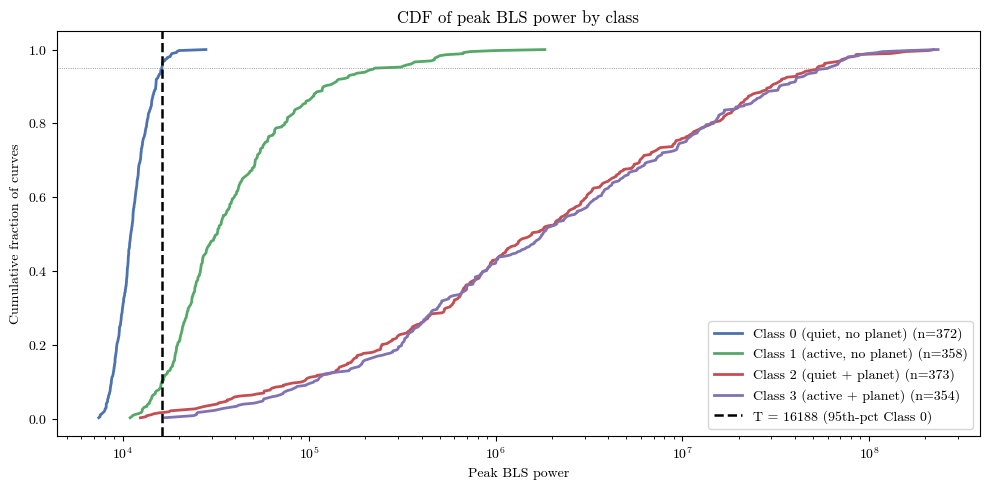

In [5]:
class0_mask = bls_df["label"] == 0
THRESHOLD   = float(np.percentile(bls_df.loc[class0_mask, "bls_power"], 95))
print(f"Detection threshold (95th-pct, Class 0): {THRESHOLD:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for cls in range(4):
    vals = np.sort(bls_df.loc[bls_df["label"]==cls, "bls_power"].values)
    y = np.arange(1, len(vals)+1) / len(vals)
    ax.plot(vals, y, lw=2, color=CLASS_COLORS[cls],
            label=f"{CLASS_LABELS[cls]} (n={len(vals)})")
ax.axvline(THRESHOLD, color="k", ls="--", lw=1.8, label=f"T = {THRESHOLD:.0f} (95th-pct Class 0)")
ax.axhline(0.95, color="gray", lw=0.6, ls=":")   # the 95th-pct Class 0 anchor
ax.set_xscale("log")
ax.set_xlabel("Peak BLS power")
ax.set_ylabel("Cumulative fraction of curves")
ax.set_title("CDF of peak BLS power by class")
ax.legend()
plt.tight_layout()
plt.show()

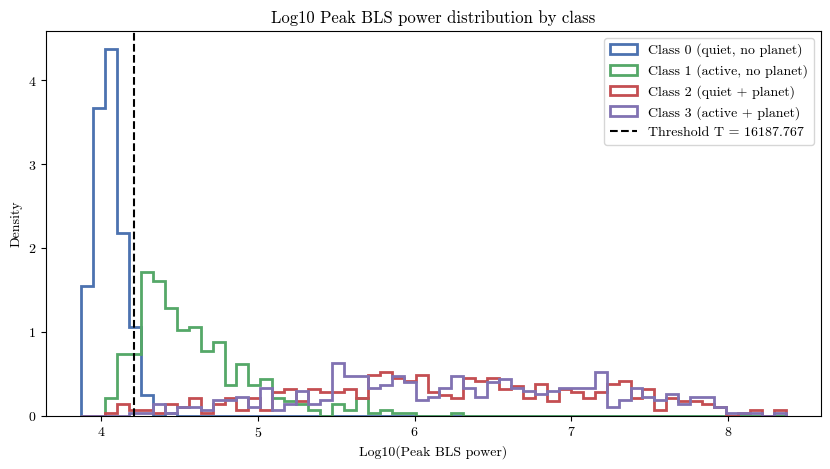

In [6]:
logp = np.log10(bls_df["bls_power"].clip(lower=1))
bins = np.linspace(logp.min(), logp.max(), 60)
fig, ax = plt.subplots(figsize=(10, 5))
for cls in range(4):
    vals = np.log10(bls_df.loc[bls_df["label"]==cls,"bls_power"].clip(lower=1))
    ax.hist(vals, bins=bins, histtype="step", lw=2,
            color=CLASS_COLORS[cls], label=CLASS_LABELS[cls], density=True)
ax.axvline(np.log10(THRESHOLD), color="k", ls="--", lw=1.5,
           label=f"Threshold T = {THRESHOLD:.3f}")
ax.legend()
ax.set_xlabel("Log10(Peak BLS power)")
ax.set_ylabel("Density")
ax.set_title("Log10 Peak BLS power distribution by class")
plt.show()

## Recovery Scoring

A planet is **recovered** when two conditions are simultaneously met:

1. **Power gate**: $\mathrm{peak\, BLS\, power} > T$
2. **Period match**: $|P_{BLS} − P_{inj}| / P_{inj} < 10 \%$

For planet-absent curves (Classes 0 & 1) the power gate alone determines whether a false positive is triggered.

In [7]:
bls_df["above_threshold"] = bls_df["bls_power"] > THRESHOLD
planet_mask = bls_df["planet_present"].fillna(0).astype(int) == 1

bls_df["period_match"] = (
    planet_mask &
    (np.abs(bls_df["bls_period"] - bls_df["planet_period_days"].fillna(np.inf))
     / bls_df["planet_period_days"].fillna(np.inf) < PERIOD_TOL)
)

# Full detection: must exceed threshold AND (no planet OR period matches)
bls_df["recovered"] = bls_df["above_threshold"] & (~planet_mask | bls_df["period_match"])

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for cls in range(4):
    sub = bls_df[bls_df["label"] == cls]
    n   = len(sub)
    at  = sub["above_threshold"].mean()
    pm  = sub["period_match"].mean() if cls in (2, 3) else float("nan")
    rec = sub["recovered"].mean()    if cls in (2, 3) else float("nan")
    rows.append(dict(
        Class=cls, n=n,
        above_threshold_pct=f"{at:.1%}",
        period_match_pct=("—" if np.isnan(pm) else f"{pm:.1%}"),
        recovered_pct=("FPR" if cls in (0, 1) else f"{rec:.1%}"),
    ))

summary = pd.DataFrame(rows)
print("=== BLS Detection Summary ===")
print(summary.to_string(index=False))

fpr0 = bls_df.loc[bls_df["label"] == 0, "above_threshold"].mean()
fpr1 = bls_df.loc[bls_df["label"] == 1, "above_threshold"].mean()
tpr2 = bls_df.loc[bls_df["label"] == 2, "recovered"].mean()
tpr3 = bls_df.loc[bls_df["label"] == 3, "recovered"].mean()

print()
print(f"FPR — Class 0 (quiet,  no planet): {fpr0:.1%}  (~ calibration target)")
print(f"FPR — Class 1 (active, no planet): {fpr1:.1%}")
print(f"TPR — Class 2 (quiet  + planet)  : {tpr2:.1%}")
print(f"TPR — Class 3 (active + planet)  : {tpr3:.1%}")
print(f"Agregated activity cost (C2 → C3 gap)      : {tpr2 - tpr3:+.1%}")

=== BLS Detection Summary ===
 Class   n above_threshold_pct period_match_pct recovered_pct
     0 372                5.1%                —           FPR
     1 358               90.5%                —           FPR
     2 373               98.4%            96.2%         96.0%
     3 354              100.0%            89.5%         89.5%

FPR — Class 0 (quiet,  no planet): 5.1%  (~ calibration target)
FPR — Class 1 (active, no planet): 90.5%
TPR — Class 2 (quiet  + planet)  : 96.0%
TPR — Class 3 (active + planet)  : 89.5%
Agregated activity cost (C2 → C3 gap)      : +6.4%


### Are "failed" recoveries actually P/2 or 2P hits?

In [8]:
planet_df = bls_df[planet_mask].copy()

print("=" * 60)
print(" ALIAS ANALYSIS (planet classes 2 & 3)")
print("=" * 60)

ratio = planet_df["bls_period"] / planet_df["planet_period_days"]
TOL = 0.05  # fractional tolerance around each harmonic

def near(r, target, tol=TOL):
    return np.abs(r - target) / target < tol

planet_df["match_1x"]   = near(ratio, 1.0)
planet_df["match_2x"]   = near(ratio, 2.0)   # BLS found twice the period
planet_df["match_half"] = near(ratio, 0.5)   # BLS found half the period
planet_df["match_3x"]   = near(ratio, 3.0)
planet_df["match_third"]= near(ratio, 1/3)
planet_df["any_alias"]  = planet_df[["match_2x","match_half",
                                     "match_3x","match_third"]].any(axis=1)

# only meaningful among curves that cleared the power gate
gated = planet_df[planet_df["bls_power"] > THRESHOLD]
for cls in (2, 3):
    s = gated[gated["label"] == cls]
    n = len(s)
    if n == 0:
        continue
    print(f"\n Class {cls}  (n={n} above threshold)")
    print(f"   exact period (1x)     : {s['match_1x'].mean():.1%}")
    print(f"   2x / half aliases     : {(s['match_2x'] | s['match_half']).mean():.1%}")
    print(f"   3x / third aliases    : {(s['match_3x'] | s['match_third']).mean():.1%}")
    print(f"   any harmonic (not 1x) : {s['any_alias'].mean():.1%}")
    missed = s[~s["match_1x"] & ~s["any_alias"]]
    print(f"   true misses (no 1x, no alias): {len(missed)}/{n} = {len(missed)/n:.1%}")

# How much would recovery rise if aliases counted as found?
print("\n Recovery, strict (1x only) vs alias-tolerant:")
for cls in (2, 3):
    s = planet_df[planet_df["label"] == cls]
    strict = (s["bls_power"] > THRESHOLD) & s["match_1x"]
    loose  = (s["bls_power"] > THRESHOLD) & (s["match_1x"] | s["any_alias"])
    print(f"   Class {cls}:  strict {strict.mean():.1%}   ->   "
          f"alias-tolerant {loose.mean():.1%}   "
          f"(+{loose.mean()-strict.mean():.1%})")

 ALIAS ANALYSIS (planet classes 2 & 3)

 Class 2  (n=367 above threshold)
   exact period (1x)     : 97.5%
   2x / half aliases     : 2.2%
   3x / third aliases    : 0.0%
   any harmonic (not 1x) : 2.2%
   true misses (no 1x, no alias): 1/367 = 0.3%

 Class 3  (n=354 above threshold)
   exact period (1x)     : 89.5%
   2x / half aliases     : 3.7%
   3x / third aliases    : 0.0%
   any harmonic (not 1x) : 3.7%
   true misses (no 1x, no alias): 24/354 = 6.8%

 Recovery, strict (1x only) vs alias-tolerant:
   Class 2:  strict 96.0%   ->   alias-tolerant 98.1%   (+2.1%)
   Class 3:  strict 89.5%   ->   alias-tolerant 93.2%   (+3.7%)


### Is the 85% FPR in Class 1 spot modulation?

In [9]:
print("\n" + "=" * 60)
print("     CLASS-1 FALSE POSITIVES — period vs rotation")
print("=" * 60)

if "rotation_period_days" in bls_df.columns:
    c1 = bls_df[(bls_df["label"] == 1) & (bls_df["bls_power"] > THRESHOLD)].copy()
    c1_ratio = c1["bls_period"] / c1["rotation_period_days"]

    for lab, lo, hi in [("near Prot (1x)", 0.95, 1.05),
                        ("near 2x Prot",   1.90, 2.10),
                        ("near 0.5x Prot", 0.45, 0.55)]:
        frac = ((c1_ratio > lo) & (c1_ratio < hi)).mean()
        print(f"   {lab:18s}: {frac:.1%}")
    print(f"   median P_BLS / P_rot : {c1_ratio.median():.2f}")
    print(f"   ({len(c1)} Class-1 curves above threshold)")
else:
    c1 = c1_ratio = None
    print("rotation_period_days not in bls_df — add it to `keep` to enable.")


     CLASS-1 FALSE POSITIVES — period vs rotation
   near Prot (1x)    : 0.0%
   near 2x Prot      : 0.3%
   near 0.5x Prot    : 0.0%
   median P_BLS / P_rot : 0.04
   (324 Class-1 curves above threshold)


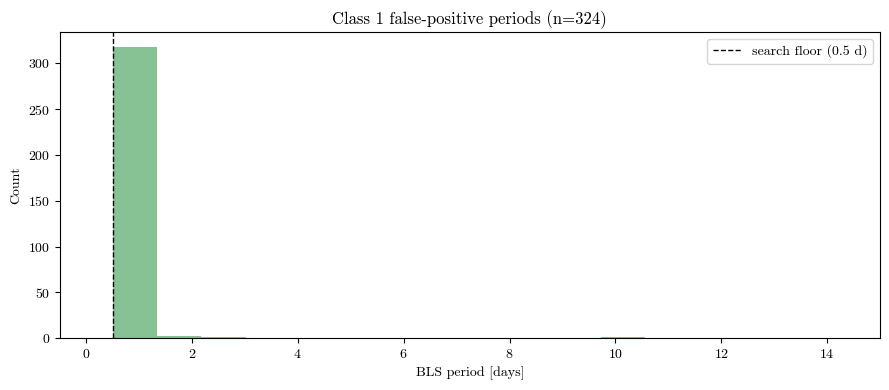

In [23]:
c1 = bls_df[(bls_df["label"] == 1) & (bls_df["bls_power"] > THRESHOLD)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(c1["bls_period"], bins=np.linspace(PERIOD_MIN, PERIOD_MAX, 60),
        color=CLASS_COLORS[1], alpha=0.7)
ax.axvline(PERIOD_MIN, color="k", ls="--", lw=1, label=f"search floor ({PERIOD_MIN} d)")
ax.set_xlim(-0.5, 15)
ax.set_xlabel("BLS period [days]")
ax.set_ylabel("Count")
ax.set_title(f"Class 1 false-positive periods (n={len(c1)})")
ax.legend()
plt.tight_layout()
plt.show()

## Stratified Recovery

Recovery fraction broken down by three axes (planet LCs only):

- **Transit depth** — shallow planets are harder to detect
- **Orbital period** — long-period planets have fewer transits over the 270-day baseline
- **Activity class** — strong activity degrades recovery

In [12]:
planet_df["depth_tier"] = pd.cut(
    planet_df["transit_depth_ppm"],
    bins=[0, 200, 500, np.inf],
    labels=["< 200 ppm", "200-500 ppm", "> 500 ppm"],
)

planet_df["period_tier"] = pd.cut(
    planet_df["planet_period_days"],
    bins=[0, 10, 30, np.inf],
    labels=["< 10 d", "10-30 d", "> 30 d"],
)

planet_df["radius_tier"] = pd.cut(
    planet_df["planet_radius_earth"],
    bins=[0.8, 1.8, 2.8, 4.0],
    labels=["< 1.8 R⊕ (super-Earth)",
            "1.8–2.8 R⊕ (sub-Neptune)",
            "> 2.8 R⊕ (large)"],
)

def fmt_tab(df, by):
    tab = (df.groupby(by, observed=True)["recovered"]
             .agg(n="count", recovery="mean")
             .assign(recovery=lambda x: x["recovery"].map("{:.1%}".format)))
    return tab


print("Recovery by radius tier x class:")
print(fmt_tab(planet_df, ["radius_tier", "label"]).to_string())
print()
print("Recovery by depth tier x class:")
print(fmt_tab(planet_df, ["depth_tier", "label"]).to_string())
print()
print("Recovery by period tier x class:")
print(fmt_tab(planet_df, ["period_tier", "label"]).to_string())

Recovery by radius tier x class:
                                  n recovery
radius_tier              label              
< 1.8 R⊕ (super-Earth)   2      166    94.0%
                         3      141    83.0%
1.8–2.8 R⊕ (sub-Neptune) 2      127    96.1%
                         3      124    92.7%
> 2.8 R⊕ (large)         2       80   100.0%
                         3       89    95.5%

Recovery by depth tier x class:
                     n recovery
depth_tier  label              
< 200 ppm   2      148    93.2%
            3      137    82.5%
200-500 ppm 2      136    96.3%
            3      122    91.8%
> 500 ppm   2       89   100.0%
            3       95    96.8%

Recovery by period tier x class:
                     n recovery
period_tier label              
< 10 d      2      141   100.0%
            3      140    98.6%
10-30 d     2      159    98.1%
            3      131    93.9%
> 30 d      2       73    83.6%
            3       83    67.5%


### BLS-recovered depth vs injected depth

In [13]:
print("\n" + "=" * 60)
print(" DEPTH RECOVERY (period-matched planets only)")
print("=" * 60)

matched = planet_df[(planet_df["bls_power"] > THRESHOLD) & planet_df["match_1x"]].copy()
matched["depth_ratio"] = matched["bls_depth_ppm"] / matched["transit_depth_ppm"]
for cls in (2, 3):
    s = matched[matched["label"] == cls]["depth_ratio"]
    if len(s):
        print(f"   Class {cls}:  median recovered/injected depth = {s.median():.2f}  "
              f"(n={len(s)})")


 DEPTH RECOVERY (period-matched planets only)
   Class 2:  median recovered/injected depth = 0.90  (n=358)
   Class 3:  median recovered/injected depth = 0.89  (n=317)


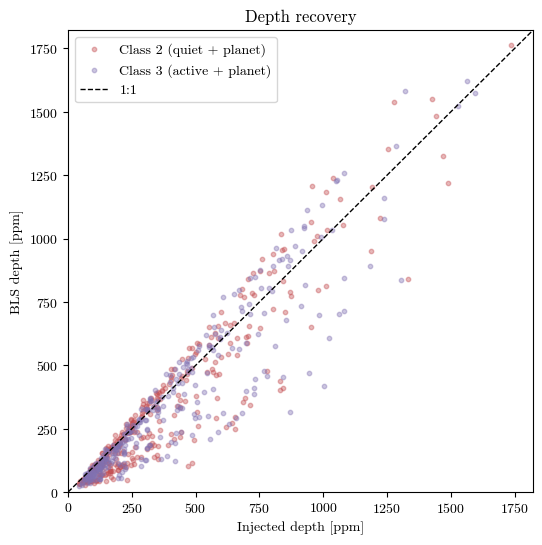

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
for cls in (2, 3):
    s = matched[matched["label"] == cls]
    ax.scatter(s["transit_depth_ppm"], s["bls_depth_ppm"],
               s=10, alpha=0.4, color=CLASS_COLORS[cls], label=CLASS_LABELS[cls])
if len(matched):
    dmax = matched["transit_depth_ppm"].max() * 1.05
    ax.plot([0, dmax], [0, dmax], "k--", lw=1, label="1:1")
    ax.set_xlim(0, dmax); ax.set_ylim(0, dmax)

ax.set_xlabel("Injected depth [ppm]")
ax.set_ylabel("BLS depth [ppm]")
ax.legend()
ax.set_title("Depth recovery")
plt.show()

## Visualizations

In [15]:
def bls_for_plot(lc_pos):
    """Re-run the full BLS pipeline for one LC by integer position; returns plot objects."""
    t_b, f_b = bin_lc(time_days, flux_all[lc_pos])
    f_norm   = 1.0 + f_b / 1e4
    flat, _  = flatten(t_b, f_norm, method="biweight",
                       window_length=WINDOW_D, return_trend=True)
    f_det    = (flat - 1.0) * 1e4
    freqs    = np.linspace(1/PERIOD_MAX, 1/PERIOD_MIN, N_PERIODS)
    periods  = 1 / freqs
    bls      = BoxLeastSquares(t_b, f_det)
    res      = bls.power(periods, DURATIONS_D, oversample=1, method="fast")
    bi       = int(np.argmax(res.power))
    return t_b, f_det, res, bls, bi

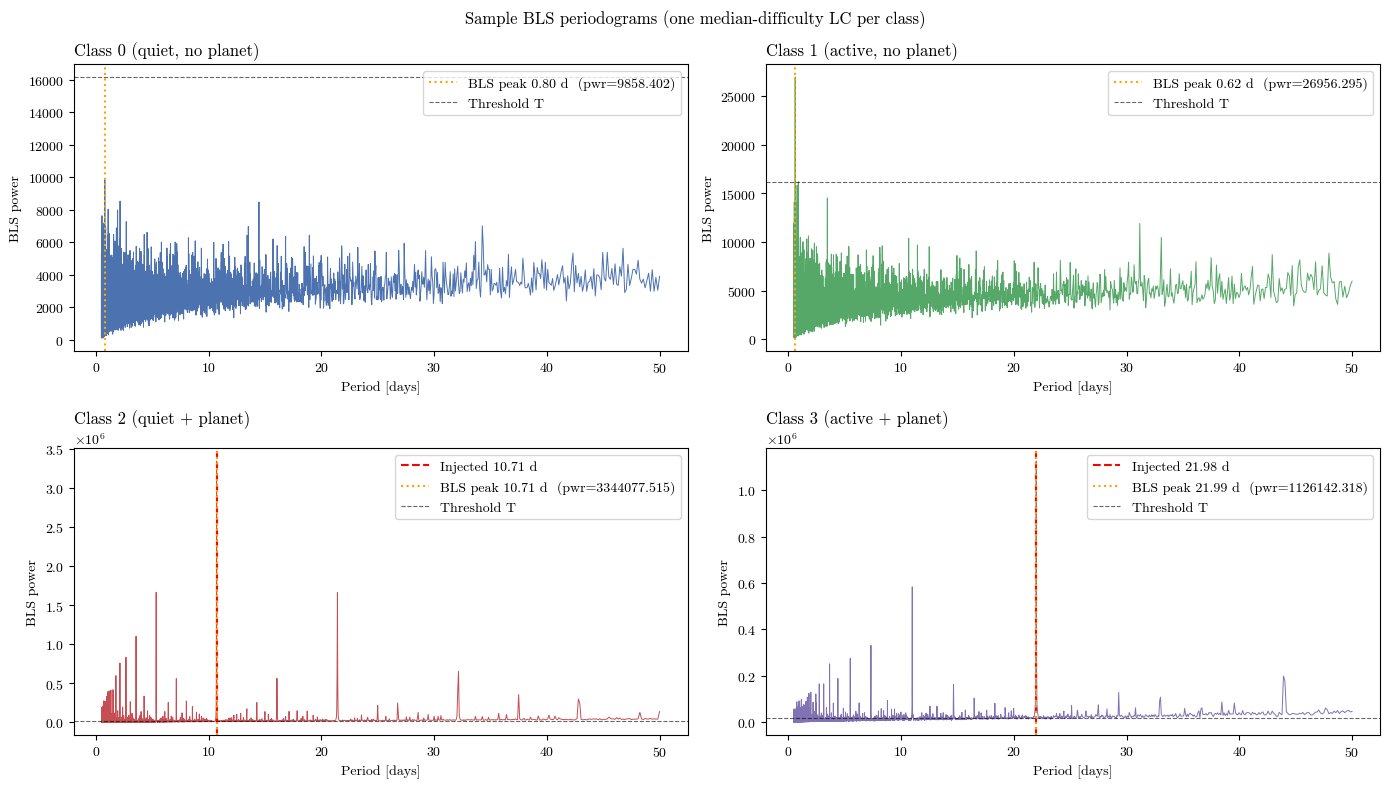

In [16]:
# Pick one representative LC per class
# Planet classes: median-depth example for a 'typical difficulty' look
example_idxs = {}
for cls in range(4):
    cls_rows = np.where(labels == cls)[0]
    if cls in (2, 3):
        depths = np.array([
            meta.at[file_ids[i], "transit_depth_ppm"]
            if file_ids[i] in meta.index else np.nan
            for i in cls_rows
        ])
        med_d   = np.nanmedian(depths)
        pick    = cls_rows[np.nanargmin(np.abs(depths - med_d))]
    else:
        pick = cls_rows[0]
    example_idxs[cls] = int(pick)

# Fig 2 — 2×2 grid of BLS periodograms (one per class)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for cls, ax in zip(range(4), axes.flatten()):
    idx              = example_idxs[cls]
    t_b, f_det, res, bls, bi = bls_for_plot(idx)
    bp   = float(res.period[bi])
    bpow = float(res.power[bi])

    ax.plot(res.period, res.power, lw=0.7, color=CLASS_COLORS[cls])

    if cls in (2, 3):
        fid   = file_ids[idx]
        p_inj = meta.at[fid, "planet_period_days"] if fid in meta.index else None
        if p_inj:
            ax.axvline(p_inj, color="red", ls="--", lw=1.5,
                       label=f"Injected {p_inj:.2f} d")
    ax.axvline(bp, color="orange", ls=":", lw=1.5,
               label=f"BLS peak {bp:.2f} d  (pwr={bpow:.3f})")
    ax.axhline(THRESHOLD, color="k", ls="--", lw=0.8, alpha=0.6, label="Threshold T")

    ax.set_xlabel("Period [days]")
    ax.set_ylabel("BLS power")
    ax.set_title(CLASS_LABELS[cls], loc="left")
    ax.legend()

fig.suptitle("Sample BLS periodograms (one median-difficulty LC per class)")
plt.tight_layout()
plt.show()

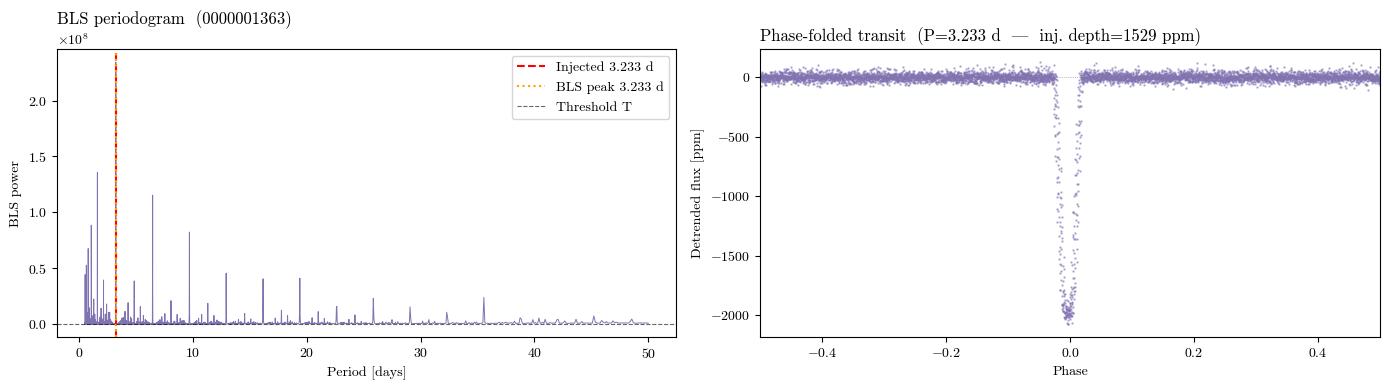

In [17]:
# Best recovered Class 3 LC (highest BLS power among period-matched detections)
pos_of = {fid: i for i, fid in enumerate(file_ids)}

rec3 = bls_df[(bls_df["label"] == 3) & bls_df["period_match"]]
if rec3.empty:
    rec3 = bls_df[(bls_df["label"] == 3) & bls_df["above_threshold"]]

best_fid = rec3["bls_power"].idxmax()          # file_id string (the index label)
row      = bls_df.loc[best_fid]                # label lookup
best_pos = pos_of[best_fid]                     # integer position into flux_all

t_b, f_det, res, bls, bi = bls_for_plot(best_pos)
bp  = float(res.period[bi])
bd  = float(res.duration[bi])
bt0 = float(res.transit_time[bi])

fid   = best_fid                                # file_id is the index, not a column
p_inj = float(row["planet_period_days"]) if not pd.isna(row.get("planet_period_days")) else None
d_inj = float(row["transit_depth_ppm"])  if not pd.isna(row.get("transit_depth_ppm"))  else None

phase = ((t_b - bt0) % bp) / bp
phase[phase > 0.5] -= 1.0
srt   = np.argsort(phase)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# BLS periodogram
ax1.plot(res.period, res.power, lw=0.7, color=CLASS_COLORS[3])
if p_inj:
    ax1.axvline(p_inj, color="red",    ls="--", lw=1.5, label=f"Injected {p_inj:.3f} d")
ax1.axvline(bp,    color="orange", ls=":",  lw=1.5, label=f"BLS peak {bp:.3f} d")
ax1.axhline(THRESHOLD, color="k", ls="--", lw=0.8, alpha=0.6, label="Threshold T")
ax1.set_xlabel("Period [days]"); ax1.set_ylabel("BLS power")
ax1.set_title(f"BLS periodogram  ({fid})", loc="left")
ax1.legend()

# Phase-folded detrended LC
ax2.plot(phase[srt], f_det[srt], ".", ms=1.5, alpha=0.5,
         color=CLASS_COLORS[3], rasterized=True)
ax2.axhline(0, color="gray", lw=0.5, ls=":")
label_str = f"P={bp:.3f} d"
if d_inj:
    label_str += f"  |  inj. depth={d_inj:.0f} ppm"
ax2.set_xlabel("Phase"); ax2.set_ylabel("Detrended flux [ppm]")
ax2.set_title(f"Phase-folded transit  ({label_str})", loc="left")
ax2.set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

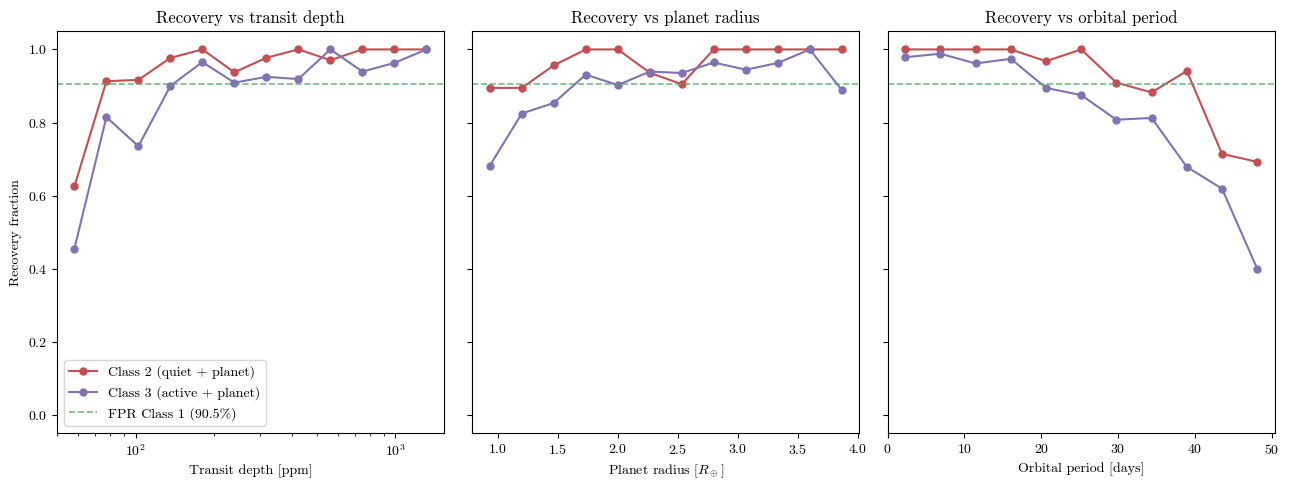

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 5),sharey=True)

depth_bins  = np.logspace(np.log10(50),  np.log10(1500), 13)
period_bins = np.linspace(0, 55, 13)
radius_bins = np.linspace(0.8, 4.0, 13) 

for cls in (2, 3):
    sub   = planet_df[planet_df["label"] == cls]
    color = CLASS_COLORS[cls]
    label = CLASS_LABELS[cls]

    # Recovery vs transit depth
    rec_d, _, bn = binned_statistic(
        sub["transit_depth_ppm"], sub["recovered"].astype(float),
        statistic="mean", bins=depth_bins)
    cnt_d, _, _  = binned_statistic(
        sub["transit_depth_ppm"], sub["recovered"].astype(float),
        statistic="count", bins=depth_bins)
    mid_d = 0.5 * (depth_bins[:-1] + depth_bins[1:])
    good  = cnt_d >= 5
    ax1.plot(mid_d[good], rec_d[good], "o-", color=color, label=label, lw=1.5, ms=5)

    # Recovery vs planet radius
    rec_r, _, _  = binned_statistic(
        sub["planet_radius_earth"], sub["recovered"].astype(float),
        statistic="mean", bins=radius_bins)
    cnt_r, _, _  = binned_statistic(
        sub["planet_radius_earth"], sub["recovered"].astype(float),
        statistic="count", bins=radius_bins)
    mid_r = 0.5 * (radius_bins[:-1] + radius_bins[1:])
    good  = cnt_r >= 5
    ax2.plot(mid_r[good], rec_r[good], "o-", color=color, label=label, lw=1.5, ms=5)

    # Recovery vs orbital period
    rec_p, _, _  = binned_statistic(
        sub["planet_period_days"], sub["recovered"].astype(float),
        statistic="mean", bins=period_bins)
    cnt_p, _, _  = binned_statistic(
        sub["planet_period_days"], sub["recovered"].astype(float),
        statistic="count", bins=period_bins)
    mid_p = 0.5 * (period_bins[:-1] + period_bins[1:])
    good  = cnt_p >= 5
    ax3.plot(mid_p[good], rec_p[good], "o-", color=color, label=label, lw=1.5, ms=5)

# FPR references
ax1.axhline(fpr1, color=CLASS_COLORS[1], ls="--", lw=1.2, alpha=0.8,
            label=f"FPR Class 1 ({fpr1:.1%})")
ax2.axhline(fpr1, color=CLASS_COLORS[1], ls="--", lw=1.2, alpha=0.8,
            label=f"FPR Class 1 ({fpr1:.1%})")
ax3.axhline(fpr1, color=CLASS_COLORS[1], ls="--", lw=1.2, alpha=0.8,
            label=f"FPR Class 1 ({fpr1:.1%})")

ax1.set_xscale("log")
ax1.set_xlabel("Transit depth [ppm]")
ax1.set_ylabel("Recovery fraction")
ax1.set_ylim(-0.05, 1.05); ax1.set_title("Recovery vs transit depth")
ax1.legend()

ax2.set_xlabel("Planet radius [$R_\\oplus$]")
ax2.set_ylim(-0.05, 1.05); ax2.set_title("Recovery vs planet radius")

ax3.set_xlabel("Orbital period [days]")
ax3.set_ylim(-0.05, 1.05); ax3.set_title("Recovery vs orbital period")



plt.tight_layout()
plt.show()

## Phase 3 Scientific Summary

The headline result of the classical baseline — the reference point against which Phase 4 (ML) is measured.

In [19]:
print("=" * 62)
print("  Phase 3 BLS Baseline — Scientific Summary")
print("=" * 62)
print(f"  Dataset            : {n_lc} light curves")
print(f"  Cadence (binned)   : 1 h  ({BIN_FACTOR}× from {cadence_s:.0f} s)")
print(f"  Detection threshold: {THRESHOLD:.4f}  (95th-pct Class 0 peak power)")
print()
print(f"  False positive rate")
print(f"    Class 0 (quiet,  no planet): {fpr0:.1%}  ← calibration target")
print(f"    Class 1 (active, no planet): {fpr1:.1%}  ← activity inflation")
print()
print(f"  Transit recovery rate")
print(f"    Class 2 (quiet  + planet)  : {tpr2:.1%}")
print(f"    Class 3 (active + planet)  : {tpr3:.1%}")
print(f"    Activity cost (C2 → C3)    : {tpr2 - tpr3:+.1%}")
print("=" * 62)

  Phase 3 BLS Baseline — Scientific Summary
  Dataset            : 1457 light curves
  Cadence (binned)   : 1 h  (6× from 600 s)
  Detection threshold: 16187.7669  (95th-pct Class 0 peak power)

  False positive rate
    Class 0 (quiet,  no planet): 5.1%  ← calibration target
    Class 1 (active, no planet): 90.5%  ← activity inflation

  Transit recovery rate
    Class 2 (quiet  + planet)  : 96.0%
    Class 3 (active + planet)  : 89.5%
    Activity cost (C2 → C3)    : +6.4%


## Save Results

`bls_results.csv` carries the per-LC BLS statistics, ground-truth labels, and recovery flags.
Phase 4 loads this file to benchmark the ML classifier against the classical baseline.

In [20]:
out_path = DATA_DIR / "bls_results.csv"
bls_df.to_csv(out_path)
print(f"Saved {len(bls_df)} rows → {out_path}")
print(f"Columns: {list(bls_df.columns)}")

Saved 1457 rows → /Users/isaac/Documents/MASS/Academic/2nd-semester/Computational-Astrobiology/project/data/bls_results.csv
Columns: ['bls_period', 'bls_duration', 'bls_t0', 'bls_power', 'bls_depth_ppm', 'bls_depth_err_ppm', 'label', 'activity_class', 'planet_present', 'planet_period_days', 'transit_depth_ppm', 'planet_radius_earth', 'star_mass_msun', 'star_radius_rsun', 'rotation_period_days', 'above_threshold', 'period_match', 'recovered']


## Conclusions

The BLS + Wotan baseline establishes the classical reference point for Phase 4. The transit search is **blind**: the period grid (0.5–50 d) is set from instrument and baseline considerations only, with no reference to the injected parameters, which enter solely at the scoring stage.

**Detection performance.** Calibrated to a 5% false-positive rate on quiet stars (Class 0), the baseline recovers **96.0%** of transits around quiet hosts (Class 2) and **89.5%** around active hosts (Class 3) under strict period matching. Because the wide blind search admits short-period aliases, ~2–4% of true detections land on a 1/2x or 1/3x harmonic; counting these, alias-tolerant recovery rises to **98.1% (Class 2)** and **93.2% (Class 3)**. Either way, the activity cost is modest in aggregate (~4–6 points) but strongly **conditional**: negligible for deep, short-period planets and severe in the shallow, long-period corner - a ~16-point C2->C3 gap for P > 30 d, and an ~11-point gap below 1.8 $R_{\oplus}$. This is where classical detection begins to fail.

**The headline failure is the false-positive rate on active stars.** With the threshold fixed by quiet-star noise, **90.5%** of active planetless stars (Class 1) still trigger a detection. Diagnostics rule out rotation-period locking decisively: essentially none of the false positives fall near the rotation period or its harmonics (median P_BLS/P_rot ≈ 0.04). Instead they are overwhelmingly **short-period detections** — the recovered period piles up below ~1 day, at the floor of the search grid, where correlated activity residual surviving detrending can always be fit by a narrow box and where the large number of trial phases inflates the peak statistic. The false positives are therefore not the activity signal being mistaken for a transit, but the box search manufacturing implausibly short-period candidates from residual structure. A single power threshold cannot separate this from genuine transits — the central motivation for a learned classifier.

**Validation.** Depth recovery is biased low by ~10% (median recovered/injected depth 0.90 quiet, 0.89 active) — a boxcar-plus-residual effect, roughly independent of activity, that a limb-darkened template (TLS) would reduce. Aliasing, quantified above, is the main caveat on the recovery figures and is bounded at a few percent.

**Handoff to Phase 4.** `bls_results.csv` provides the per-curve benchmark. The bar ML must clear is twofold: match the ~90–96% transit recovery *while* driving the Class 1 false-positive rate far below 90% — the discrimination that a blind box search structurally cannot achieve.